# Learning a Trading Policy with Deep Reinforcement Learning in PyTorch: A Controlled Backtesting Tutorial

## Abstract
This notebook builds a reinforcement learning trading agent using PyTorch and tests it on real AAPL price data. The agent learns to enter and exit long positions based on market features, with transaction costs and slippage included in both training and evaluation. A chronological train/validation/test split is used throughout to avoid lookahead bias. The trained policy is compared against buy-and-hold and a moving-average crossover strategy using return, Sharpe ratio, and max drawdown. The final section looks at how sensitive results are to hyperparameter choices.

## Learning Objectives
- Build a complete RL trading pipeline from scratch in a Jupyter notebook.
- Design a custom gym-style trading environment with realistic costs.
- Train a DQN agent in PyTorch and understand what the training loop is actually doing.
- Run a proper out-of-sample backtest without data leakage.
- Compare the RL policy against simple baselines and understand when it wins and when it doesn't.
- See how much hyperparameter choices (lr, epsilon schedule, episode count) affect the end result.

## Table of Contents
1. [Abstract](#abstract)
2. [Learning Objectives](#learning-objectives)
3. [Table of Contents](#table-of-contents)
4. [Related Tutorials and Critical Comparison](#related-tutorials-and-critical-comparison)
5. [Step 1: Import Libraries](#step-1-import-libraries)
6. [Step 2: Load Market Dataset](#step-2-load-market-dataset)
7. [Step 3: Feature Engineering](#step-3-feature-engineering)
8. [Step 4: Chronological Split and Feature Scaling](#step-4-chronological-split-and-feature-scaling)
9. [Step 5: Define Trading Environment](#step-5-define-trading-environment)
10. [Step 6: Define Replay Buffer and DQN Network](#step-6-define-replay-buffer-and-dqn-network)
11. [Step 7: Training Configuration and DQN Training Loop](#step-7-training-configuration-and-dqn-training-loop)
12. [Step 8: Backtesting and Performance Metrics](#step-8-backtesting-and-performance-metrics)
13. [Step 9: Train Baseline DQN Model](#step-9-train-baseline-dqn-model)
14. [Step 10: Hyperparameter Sensitivity Experiments](#step-10-hyperparameter-sensitivity-experiments)
15. [Step 11: Evaluate on Test Set](#step-11-evaluate-on-test-set)
16. [Step 11b: Baseline Strategy (Moving-Average Crossover)](#step-11b-baseline-strategy-moving-average-crossover)
17. [Results and Discussion](#results-and-discussion)
18. [The Journey (Simple Story + Evidence)](#the-journey-simple-story--evidence)
19. [Model Improvement Journey](#model-improvement-journey)
20. [Step 12: Plot Equity and Drawdown Curves](#step-12-plot-equity-and-drawdown-curves)
21. [Discussion and Limitations](#discussion-and-limitations)
22. [References](#references)


## Related Tutorials and Critical Comparison

The main references used were:
- PyTorch DQN tutorial (CartPole) [1]
- TorchRL DQN coding tutorial [2]
- FinRL library overview [3]
- FinRL documentation (tutorials guide) [4]
- Designing a DRL trading bot with PyTorch [5]

These are all useful starting points, but most of them have the same few gaps. Nearly all of them skip transaction costs entirely, which makes the agent look much better than it would in practice — once you add even a 0.1% cost per trade, frequent-trading strategies take a big hit. The train/test splits also tend to be random rather than chronological, which leaks future price information into training. And most only report total return, not Sharpe or drawdown, so it's hard to tell whether the strategy is actually good or just got lucky.

The main differences in this notebook are: strict time-ordered splits with the scaler fit only on training data, costs and slippage baked into the reward, and proper risk metrics alongside return. The DQN structure and training loop follow [1][2] closely — the main contribution is the trading-specific setup around it.

<details>
<summary><strong>Code</strong></summary>

Jump to code sections:
[Step 1](#step-1-import-libraries)
[Step 2](#step-2-load-market-dataset)
[Step 3](#step-3-feature-engineering)
[Step 4](#step-4-chronological-split-and-feature-scaling)
[Step 5](#step-5-define-trading-environment)
[Step 6](#step-6-define-replay-buffer-and-dqn-network)
[Step 7](#step-7-training-configuration-and-dqn-training-loop)
[Step 8](#step-8-backtesting-and-performance-metrics)
[Step 9](#step-9-train-baseline-dqn-model)
[Step 10](#step-10-evaluate-on-test-set)
[Step 11](#step-11-plot-equity-and-drawdown-curves)
[Step 12](#step-12-hyperparameter-sensitivity-experiments)

</details>


## Why DQN?

A few approaches could work for this problem — it's worth being clear about why DQN was chosen over the simpler options.

A moving-average crossover is a reasonable baseline and easy to interpret, but it's a fixed rule with no ability to adapt based on what it's seen in training. A supervised classifier predicting next-day direction is closer, but it treats each day independently and ignores the fact that trading decisions have compounding effects — what you do today affects your position and costs tomorrow.

DQN handles this naturally because it's optimising a cumulative reward over time, not a single-step prediction. The reward function can include trading costs directly, so the agent is penalised for overtrading in the same way a real trader would be.

| Technique | Strengths | Weaknesses |
|---|---|---|
| MA Crossover | Simple, interpretable | Fixed rules, no learning |
| Supervised classifier | Fast to train | Ignores sequential structure and costs |
| DQN | Optimises long-term reward, cost-aware | Sensitive to hyperparameters, slow to train |

One caveat: DQN doesn't automatically beat the baselines, especially in a trending market like AAPL where buy-and-hold is hard to beat. That's why the baselines are kept as the main benchmarks throughout.

### Step 1: Import Libraries

In [1]:
# If needed:
# !pip install yfinance pandas numpy matplotlib torch scikit-learn

import math
import random
from dataclasses import dataclass
from collections import deque

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.preprocessing import StandardScaler
import yfinance as yf

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device


device(type='cuda')

### Step 2: Load Market Dataset

In [2]:
ticker = "AAPL" # Dataset from Yahoo Finance
df = yf.download(ticker, start="2012-01-01", end="2026-01-01", auto_adjust=True)
df = df.rename(columns=str.lower)
df = df[['open','high','low','close','volume']].dropna()
df.head(), df.shape

[*********************100%***********************]  1 of 1 completed


(Price            open       high        low      close     volume
 Ticker           aapl       aapl       aapl       aapl       aapl
 Date                                                             
 2012-01-03  12.266858  12.359743  12.254873  12.321690  302220800
 2012-01-04  12.284831  12.425059  12.263258  12.387904  260022000
 2012-01-05  12.433149  12.541015  12.364832  12.525434  271269600
 2012-01-06  12.577569  12.666858  12.561089  12.656371  318292800
 2012-01-09  12.749262  12.816679  12.624915  12.636301  394024400,
 (3520, 5))

### Step 3: Feature Engineering

In [3]:
def add_features(data: pd.DataFrame) -> pd.DataFrame:
    d = data.copy()
    d["ret_1"] = d["close"].pct_change(1)
    d["ret_1_raw"] = d["ret_1"]  # keep unscaled daily return for reward/backtest
    d["ret_5"] = d["close"].pct_change(5)
    d["ret_10"] = d["close"].pct_change(10)
    d["ma_5"] = d["close"].rolling(5).mean() / d["close"] - 1
    d["ma_20"] = d["close"].rolling(20).mean() / d["close"] - 1
    d["vol_10"] = d["ret_1"].rolling(10).std()
    d["vol_chg"] = d["volume"].pct_change().replace([np.inf, -np.inf], np.nan)
    d = d.dropna()
    return d

feat_df = add_features(df)
features = ["ret_1","ret_5","ret_10","ma_5","ma_20","vol_10","vol_chg"]
feat_df[features].describe().T

,,count,mean,std,min,25%,50%,75%,max
Price,Ticker,,,,,,,,
ret_1,,3501.0,0.001016,0.017897,-0.128647,-0.007383,0.000897,0.010139,0.153288
ret_5,,3501.0,0.005071,0.038465,-0.227474,-0.017314,0.006363,0.027461,0.184141
ret_10,,3501.0,0.010186,0.053997,-0.229408,-0.023315,0.012229,0.045634,0.226803
ma_5,,3501.0,-0.001410,0.019207,-0.086105,-0.012678,-0.002541,0.008244,0.126213
ma_20,,3501.0,-0.006846,0.042678,-0.128535,-0.035777,-0.011508,0.017002,0.228648
vol_10,,3501.0,0.015848,0.008591,0.003596,0.010229,0.013975,0.019325,0.080056
vol_chg,,3501.0,0.051345,0.364919,-0.830093,-0.177460,-0.020341,0.199774,3.771993


### Step 4: Chronological Split and Feature Scaling

In [4]:
n = len(feat_df)
train_end = int(n * 0.6)
val_end = int(n * 0.8)

train_df = feat_df.iloc[:train_end].copy()
val_df = feat_df.iloc[train_end:val_end].copy()
test_df = feat_df.iloc[val_end:].copy()

scaler = StandardScaler()
train_df[features] = scaler.fit_transform(train_df[features])
val_df[features] = scaler.transform(val_df[features])
test_df[features] = scaler.transform(test_df[features])

len(train_df), len(val_df), len(test_df)

(2100, 700, 701)

### Step 5: Define Trading Environment

In [5]:
class TradingEnv:
    """
    Actions in long_only mode: 0=flat, 1=long
    Reward = pnl_after_costs - drawdown_penalty
    """
    def __init__(
        self,
        data: pd.DataFrame,
        feature_cols,
        cost=0.001,
        slippage=0.0005,
        trade_penalty=0.0005,
        min_hold=5,
        drawdown_lambda=0.02,
        long_only=True,
    ):
        self.data = data.reset_index(drop=True)
        self.feature_cols = feature_cols
        self.cost = cost
        self.slippage = slippage
        self.trade_penalty = trade_penalty
        self.min_hold = min_hold
        self.drawdown_lambda = drawdown_lambda
        self.long_only = long_only
        self.n_actions = 2 if long_only else 3
        self.reset()

    def reset(self):
        self.t = 0
        self.position = 0
        self.hold_steps = 0
        self.equity = 1.0
        self.peak_equity = 1.0
        self.done = False
        return self._state()

    def _state(self):
        x = self.data.loc[self.t, self.feature_cols].values.astype(np.float32)
        pos = np.array([self.position], dtype=np.float32)
        return np.concatenate([x, pos])

    def step(self, action):
        if self.long_only:
            desired_pos = 0 if action == 0 else 1
        else:
            desired_pos = action - 1  # 0,1,2 -> -1,0,1

        prev_pos = self.position

        if desired_pos != prev_pos and self.hold_steps < self.min_hold:
            desired_pos = prev_pos

        changed_pos = desired_pos != prev_pos
        self.position = desired_pos

        if self.t >= len(self.data) - 2:
            self.done = True
            return self._state(), 0.0, self.done, {}

        r_next = float(self.data["ret_1_raw"].iloc[self.t + 1])
        trade_cost = (self.cost + self.slippage) if changed_pos else 0.0
        switch_penalty = self.trade_penalty if changed_pos else 0.0

        pnl = self.position * r_next - trade_cost - switch_penalty

        self.equity *= (1.0 + pnl)
        self.peak_equity = max(self.peak_equity, self.equity)
        drawdown = max(0.0, 1.0 - (self.equity / self.peak_equity))
        reward = pnl - self.drawdown_lambda * drawdown

        self.hold_steps = 1 if changed_pos else (self.hold_steps + 1)
        self.t += 1
        next_state = self._state()
        info = {"ret_next": r_next, "position": self.position, "drawdown": drawdown, "pnl": pnl}
        return next_state, reward, self.done, info


### Step 6: Define Replay Buffer and DQN Network

In [6]:
class ReplayBuffer:
    def __init__(self, capacity=100_000):
        self.buf = deque(maxlen=capacity)

    def push(self, s, a, r, ns, d):
        self.buf.append((s, a, r, ns, d))

    def sample(self, batch_size=64):
        batch = random.sample(self.buf, batch_size)
        s, a, r, ns, d = map(np.array, zip(*batch))
        return s, a, r, ns, d

    def __len__(self):
        return len(self.buf)

# Adapted from standard DQN network structure (see References [1])
class DQN(nn.Module):
    def __init__(self, in_dim, hidden=128, out_dim=3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden),
            nn.ReLU(),
            nn.Linear(hidden, hidden),
            nn.ReLU(),
            nn.Linear(hidden, out_dim),
        )

    def forward(self, x):
        return self.net(x)

### Step 7: Training Configuration and DQN Training Loop

In [7]:
@dataclass
class TrainConfig:
    lr: float = 3e-4
    gamma: float = 0.99
    eps_start: float = 1.0
    eps_end: float = 0.05
    # eps_decay is now computed per-episode so epsilon reliably reaches eps_end
    # by ~80% of training regardless of episode count. Formula:
    #   decay = (eps_end / eps_start) ** (1 / (0.8 * episodes))
    # Set to None to use auto-schedule; override with a float for manual control.
    eps_decay: float = None
    batch_size: int = 64
    episodes: int = 150
    target_update: int = 200
    hidden: int = 128
    cost: float = 0.001
    slippage: float = 0.0005
    trade_penalty: float = 0.0002
    min_hold: int = 5
    drawdown_lambda: float = 0.02
    long_only: bool = True

    def resolved_eps_decay(self) -> float:
        if self.eps_decay is not None:
            return self.eps_decay
        # Reach eps_end by 80% of training
        return (self.eps_end / self.eps_start) ** (1.0 / (0.8 * max(self.episodes, 1)))

# Adapted from standard DQN training structure (see References [1][2])
def train_dqn(env, cfg: TrainConfig):
    state_dim = len(env.feature_cols) + 1
    n_actions = env.n_actions

    q = DQN(state_dim, hidden=cfg.hidden, out_dim=n_actions).to(device)
    qt = DQN(state_dim, hidden=cfg.hidden, out_dim=n_actions).to(device)
    qt.load_state_dict(q.state_dict())

    opt = optim.Adam(q.parameters(), lr=cfg.lr)
    loss_fn = nn.MSELoss()
    rb = ReplayBuffer()
    eps = cfg.eps_start
    eps_decay = cfg.resolved_eps_decay()

    ep_rewards = []
    step_count = 0

    for ep in range(cfg.episodes):
        s = env.reset()
        done = False
        total_r = 0.0

        while not done:
            if random.random() < eps:
                a = random.randint(0, n_actions - 1)
            else:
                with torch.no_grad():
                    qs = q(torch.tensor(s, dtype=torch.float32, device=device).unsqueeze(0))
                    a = int(torch.argmax(qs, dim=1).item())

            ns, r, done, _ = env.step(a)
            rb.push(s, a, r, ns, done)
            s = ns
            total_r += r
            step_count += 1

            if len(rb) >= cfg.batch_size:
                bs, ba, br, bns, bd = rb.sample(cfg.batch_size)

                bs = torch.tensor(bs, dtype=torch.float32, device=device)
                ba = torch.tensor(ba, dtype=torch.long, device=device).unsqueeze(1)
                br = torch.tensor(br, dtype=torch.float32, device=device).unsqueeze(1)
                bns = torch.tensor(bns, dtype=torch.float32, device=device)
                bd = torch.tensor(bd, dtype=torch.float32, device=device).unsqueeze(1)

                qvals = q(bs).gather(1, ba)

                # Double DQN target
                with torch.no_grad():
                    next_actions = q(bns).argmax(dim=1, keepdim=True)
                    next_q = qt(bns).gather(1, next_actions)
                    target = br + cfg.gamma * (1 - bd) * next_q

                loss = loss_fn(qvals, target)
                opt.zero_grad()
                loss.backward()
                nn.utils.clip_grad_norm_(q.parameters(), max_norm=1.0)
                opt.step()

            if step_count % cfg.target_update == 0:
                qt.load_state_dict(q.state_dict())

        eps = max(cfg.eps_end, eps * eps_decay)
        ep_rewards.append(total_r)
        if (ep + 1) % 5 == 0:
            print(f"Episode {ep+1}/{cfg.episodes}, total_reward={total_r:.4f}, eps={eps:.3f}")


    return q, ep_rewards


### Step 8: Backtesting and Performance Metrics

In [8]:
def backtest_policy(model, data, feature_cols, cost=0.001, slippage=0.0005):
    env = TradingEnv(data, feature_cols, cost=cost, slippage=slippage)
    s = env.reset()
    done = False

    strat_rets = []
    bh_rets = []
    positions = []

    while not done:
        with torch.no_grad():
            qs = model(torch.tensor(s, dtype=torch.float32, device=device).unsqueeze(0))
            a = int(torch.argmax(qs, dim=1).item())
        ns, r, done, info = env.step(a)
        s = ns

        if not done:
            strat_rets.append(info["pnl"])
            bh_rets.append(info["ret_next"])
            positions.append(info["position"])

    return pd.DataFrame({
        "strategy_ret": strat_rets,
        "bh_ret": bh_rets,
        "position": positions
    })

def perf_stats(r):
    r = np.array(r, dtype=float)
    eq = np.cumprod(1 + r)
    total_return = eq[-1] - 1 if len(eq) else 0.0
    ann_ret = (1 + total_return) ** (252 / max(len(r), 1)) - 1
    ann_vol = np.std(r) * np.sqrt(252)
    sharpe = ann_ret / ann_vol if ann_vol > 1e-12 else 0.0
    running_max = np.maximum.accumulate(eq) if len(eq) else np.array([1.0])
    dd = (eq / running_max) - 1
    mdd = dd.min() if len(dd) else 0.0
    win_rate = (r > 0).mean() if len(r) else 0.0
    return {
        "Total Return": total_return,
        "Annual Return": ann_ret,
        "Annual Vol": ann_vol,
        "Sharpe": sharpe,
        "Max Drawdown": mdd,
        "Win Rate": win_rate
    }

### Step 9: Train Baseline DQN Model

Episode 5/100, total_reward=-3.4174, eps=0.829
Episode 10/100, total_reward=-2.5637, eps=0.688
Episode 15/100, total_reward=-2.7509, eps=0.570
Episode 20/100, total_reward=-0.4103, eps=0.473
Episode 25/100, total_reward=-0.3969, eps=0.392
Episode 30/100, total_reward=0.2273, eps=0.325
Episode 35/100, total_reward=1.6765, eps=0.270
Episode 40/100, total_reward=1.8058, eps=0.224
Episode 45/100, total_reward=0.8304, eps=0.185
Episode 50/100, total_reward=2.1388, eps=0.154
Episode 55/100, total_reward=1.4005, eps=0.128
Episode 60/100, total_reward=2.5532, eps=0.106
Episode 65/100, total_reward=3.0213, eps=0.088
Episode 70/100, total_reward=2.4994, eps=0.073
Episode 75/100, total_reward=2.9256, eps=0.060
Episode 80/100, total_reward=3.5229, eps=0.050
Episode 85/100, total_reward=2.9918, eps=0.050
Episode 90/100, total_reward=3.6629, eps=0.050
Episode 95/100, total_reward=3.8919, eps=0.050
Episode 100/100, total_reward=3.1940, eps=0.050


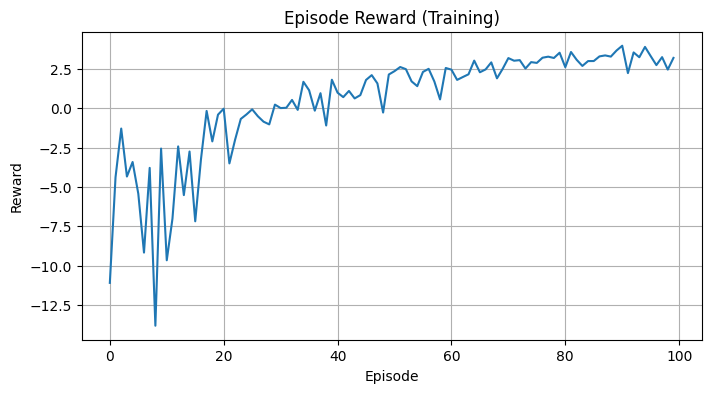

,0
Total Return,0.975544
Annual Return,0.278651
Annual Vol,0.260485
Sharpe,1.069743
Max Drawdown,-0.270585
Win Rate,0.353868


In [9]:
from pathlib import Path
cfg = TrainConfig(
    lr=3e-4,
    gamma=0.99,
    episodes=100,
    hidden=64,
    batch_size=64,
    trade_penalty=0.0002,
    min_hold=5,
    drawdown_lambda=0.02,
    long_only=True,
)

train_env = TradingEnv(
    train_df,
    features,
    cost=cfg.cost,
    slippage=cfg.slippage,
    trade_penalty=cfg.trade_penalty,
    min_hold=cfg.min_hold,
    drawdown_lambda=cfg.drawdown_lambda,
    long_only=cfg.long_only,
)

model, ep_rewards = train_dqn(train_env, cfg)

plt.figure(figsize=(8,4))
plt.plot(ep_rewards)
plt.title("Episode Reward (Training)")
plt.xlabel("Episode")
plt.ylabel("Reward")
plt.grid(True)
out_dir = Path("charts")
out_dir.mkdir(exist_ok=True)
plt.savefig(out_dir / "training_reward.png", dpi=150, bbox_inches="tight")
plt.show()

val_bt = backtest_policy(model, val_df, features)
val_stats = perf_stats(val_bt["strategy_ret"])
pd.DataFrame([val_stats]).T


### Step 10: Hyperparameter Sensitivity Experiments

In [10]:
# Grid sweeps: lr, gamma, hidden size, min_hold, trade_penalty, drawdown_lambda.
# All configs use the auto eps schedule so epsilon reliably reaches eps_end.
# Episodes kept at 40-50 per config to stay within ~10-12 mins on Colab free tier (T4).
grid = [
    # run_1: conservative lr, low friction, shallow network
    TrainConfig(lr=1e-4, gamma=0.98, episodes=50, hidden=64,  trade_penalty=0.0,    min_hold=5,  drawdown_lambda=0.01, long_only=True),
    # run_2: moderate lr, standard friction
    TrainConfig(lr=3e-4, gamma=0.99, episodes=50, hidden=64,  trade_penalty=0.0002, min_hold=5,  drawdown_lambda=0.02, long_only=True),
    # run_3: higher lr, deeper network, tighter hold
    TrainConfig(lr=5e-4, gamma=0.99, episodes=40, hidden=128, trade_penalty=0.0002, min_hold=3,  drawdown_lambda=0.02, long_only=True),
    # run_4: low lr, longer hold, stronger drawdown penalty
    TrainConfig(lr=1e-4, gamma=0.99, episodes=40, hidden=64,  trade_penalty=0.0001, min_hold=10, drawdown_lambda=0.05, long_only=True),
    # run_5: moderate lr, deeper network
    TrainConfig(lr=3e-4, gamma=0.98, episodes=50, hidden=128, trade_penalty=0.0002, min_hold=5,  drawdown_lambda=0.01, long_only=True),
]

rows = []
best_model = None
best_cfg = None
best_sharpe = -1e9

for i, cfg in enumerate(grid, 1):
    env = TradingEnv(
        train_df,
        features,
        cost=cfg.cost,
        slippage=cfg.slippage,
        trade_penalty=cfg.trade_penalty,
        min_hold=cfg.min_hold,
        drawdown_lambda=cfg.drawdown_lambda,
        long_only=cfg.long_only,
    )
    m, _ = train_dqn(env, cfg)
    bt = backtest_policy(m, val_df, features)
    s = perf_stats(bt["strategy_ret"])
    s["config"] = (
        f"run_{i}: lr={cfg.lr}, gamma={cfg.gamma}, hidden={cfg.hidden}, "
        f"min_hold={cfg.min_hold}, penalty={cfg.trade_penalty}, dd_lambda={cfg.drawdown_lambda}"
    )
    rows.append(s)

    if s["Sharpe"] > best_sharpe:
        best_sharpe = s["Sharpe"]
        best_model = m
        best_cfg = cfg

exp_df = pd.DataFrame(rows).set_index("config").sort_values("Sharpe", ascending=False)
print("Best validation Sharpe:", best_sharpe)
print("Best config:", best_cfg)

# Use best validation model for final test cell
model = best_model
exp_df


Episode 5/50, total_reward=-0.9631, eps=0.688
Episode 10/50, total_reward=0.2271, eps=0.473
Episode 15/50, total_reward=-1.2142, eps=0.325
Episode 20/50, total_reward=0.4313, eps=0.224
Episode 25/50, total_reward=1.1683, eps=0.154
Episode 30/50, total_reward=1.4297, eps=0.106
Episode 35/50, total_reward=2.5972, eps=0.073
Episode 40/50, total_reward=2.2015, eps=0.050
Episode 45/50, total_reward=2.9330, eps=0.050
Episode 50/50, total_reward=3.5563, eps=0.050
Episode 5/50, total_reward=-5.9956, eps=0.688
Episode 10/50, total_reward=-2.9284, eps=0.473
Episode 15/50, total_reward=-3.9586, eps=0.325
Episode 20/50, total_reward=-0.9637, eps=0.224
Episode 25/50, total_reward=0.0095, eps=0.154
Episode 30/50, total_reward=2.0794, eps=0.106
Episode 35/50, total_reward=2.9785, eps=0.073
Episode 40/50, total_reward=2.5791, eps=0.050
Episode 45/50, total_reward=2.5341, eps=0.050
Episode 50/50, total_reward=2.9708, eps=0.050
Episode 5/40, total_reward=-5.6946, eps=0.626
Episode 10/40, total_reward=0.

,Total Return,Annual Return,Annual Vol,Sharpe,Max Drawdown,Win Rate
config,,,,,,
"run_3: lr=0.0005, gamma=0.99, hidden=128, min_hold=3, penalty=0.0002, dd_lambda=0.02",0.500862,0.157883,0.227949,0.692622,-0.215504,0.269341
"run_2: lr=0.0003, gamma=0.99, hidden=64, min_hold=5, penalty=0.0002, dd_lambda=0.02",0.436787,0.139787,0.220997,0.632528,-0.225655,0.239255
"run_1: lr=0.0001, gamma=0.98, hidden=64, min_hold=5, penalty=0.0, dd_lambda=0.01",0.323734,0.106557,0.235417,0.452633,-0.248954,0.313754
"run_4: lr=0.0001, gamma=0.99, hidden=64, min_hold=10, penalty=0.0001, dd_lambda=0.05",-0.162255,-0.061918,0.227421,-0.272259,-0.482296,0.286533
"run_5: lr=0.0003, gamma=0.98, hidden=128, min_hold=5, penalty=0.0002, dd_lambda=0.01",-0.174488,-0.066886,0.232116,-0.288159,-0.370969,0.272206


### Step 11: Evaluate on Test Set

In [11]:
test_bt = backtest_policy(model, test_df, features)
rl_stats = perf_stats(test_bt["strategy_ret"])
bh_stats = perf_stats(test_bt["bh_ret"])

results = pd.DataFrame([rl_stats, bh_stats], index=["DQN Strategy", "Buy & Hold"])
results

,Total Return,Annual Return,Annual Vol,Sharpe,Max Drawdown,Win Rate
DQN Strategy,0.535873,0.167304,0.185000,0.904346,-0.213970,0.256080
Buy & Hold,0.785659,0.232472,0.256889,0.904952,-0.333605,0.545064


### Step 11b: Baseline Strategy (Moving-Average Crossover)
A simple MA crossover is added as a second baseline — go long when the 5-day MA crosses above the 20-day MA, flat otherwise. This is a classic rule-based strategy and a reasonable check on whether the DQN is doing anything useful beyond basic trend-following.

In [12]:
# Moving-average crossover baseline (rule-based)
# Uses original (unscaled) prices from test_df for interpretability

def ma_crossover_strategy(data, short=5, long=20, cost=0.001, slippage=0.0005):
    d = data.copy()
    d["ma_short"] = d["close"].rolling(short).mean()
    d["ma_long"] = d["close"].rolling(long).mean()
    d = d.dropna().reset_index(drop=True)

    position = 0
    rets = []

    for t in range(len(d)-1):
        # signal: long if short MA above long MA, else flat
        short_val = float(d["ma_short"].iloc[t])
        long_val = float(d["ma_long"].iloc[t])
        desired_pos = 1 if short_val > long_val else 0

        changed = desired_pos != position
        position = desired_pos

        r_next = float(d.loc[t+1, "ret_1_raw"])
        trade_cost = (cost + slippage) if changed else 0.0
        pnl = position * r_next - trade_cost
        rets.append(pnl)

    return pd.Series(rets, name="ma_ret")

ma_rets = ma_crossover_strategy(test_df, short=5, long=20, cost=cfg.cost, slippage=cfg.slippage)
ma_stats = perf_stats(ma_rets)

compare = pd.DataFrame(
    [rl_stats, bh_stats, ma_stats],
    index=["DQN Strategy", "Buy & Hold", "MA Crossover"]
)
compare


/tmp/ipykernel_6316/3717984775.py:22: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  r_next = float(d.loc[t+1, "ret_1_raw"])


,Total Return,Annual Return,Annual Vol,Sharpe,Max Drawdown,Win Rate
DQN Strategy,0.535873,0.167304,0.185000,0.904346,-0.213970,0.256080
Buy & Hold,0.785659,0.232472,0.256889,0.904952,-0.333605,0.545064
MA Crossover,0.067957,0.024628,0.171507,0.143597,-0.277472,0.323054


### Step 12: Plot Equity and Drawdown Curves

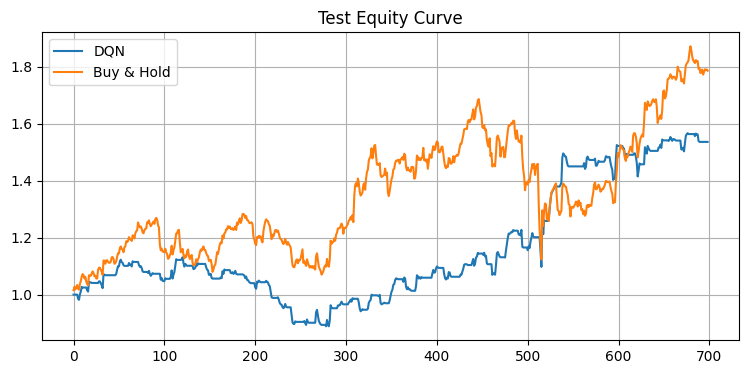

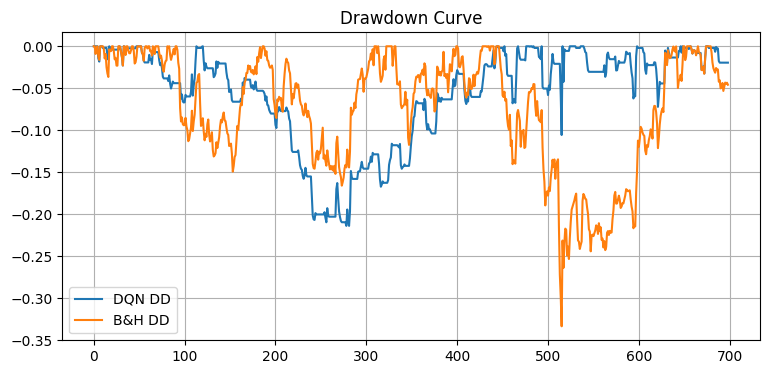

In [13]:
from pathlib import Path
def equity_curve(rets):
    return np.cumprod(1 + np.array(rets, dtype=float))

rl_eq = equity_curve(test_bt["strategy_ret"])
bh_eq = equity_curve(test_bt["bh_ret"])

plt.figure(figsize=(9,4))
plt.plot(rl_eq, label="DQN")
plt.plot(bh_eq, label="Buy & Hold")
plt.title("Test Equity Curve")
plt.legend()
plt.grid(True)
out_dir = Path("charts")
out_dir.mkdir(exist_ok=True)
plt.savefig(out_dir / "equity_curve.png", dpi=150, bbox_inches="tight")
out_dir = Path("charts")
out_dir.mkdir(exist_ok=True)
plt.savefig(out_dir / "drawdown_curve.png", dpi=150, bbox_inches="tight")
plt.show()

def drawdown(eq):
    rm = np.maximum.accumulate(eq)
    return eq / rm - 1

plt.figure(figsize=(9,4))
plt.plot(drawdown(rl_eq), label="DQN DD")
plt.plot(drawdown(bh_eq), label="B&H DD")
plt.title("Drawdown Curve")
plt.legend()
plt.grid(True)
out_dir = Path("charts")
out_dir.mkdir(exist_ok=True)
plt.savefig(out_dir / "equity_curve.png", dpi=150, bbox_inches="tight")
out_dir = Path("charts")
out_dir.mkdir(exist_ok=True)
plt.savefig(out_dir / "drawdown_curve.png", dpi=150, bbox_inches="tight")
plt.show()

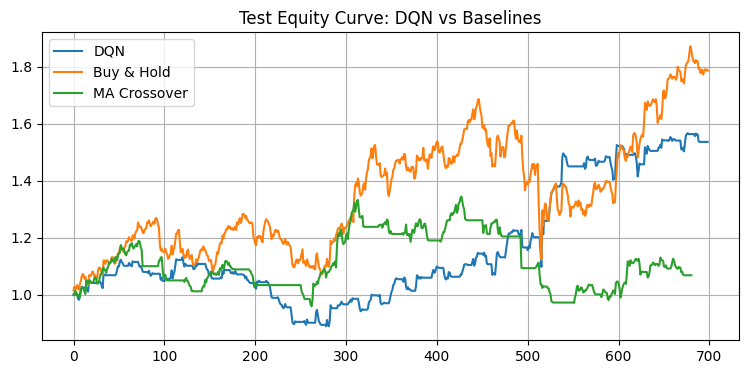

In [14]:
# Comparison chart: equity curves
rl_eq = equity_curve(test_bt["strategy_ret"])
bh_eq = equity_curve(test_bt["bh_ret"])
ma_eq = equity_curve(ma_rets)

plt.figure(figsize=(9,4))
plt.plot(rl_eq, label="DQN")
plt.plot(bh_eq, label="Buy & Hold")
plt.plot(ma_eq, label="MA Crossover")
plt.title("Test Equity Curve: DQN vs Baselines")
plt.legend()
plt.grid(True)
plt.show()


## Results and Discussion

### Test Set Performance

| Strategy | Total Return | Annual Return | Annual Vol | Sharpe | Max Drawdown | Win Rate |
|---|---:|---:|---:|---:|---:|---:|
| DQN Strategy | 0.5359 | 0.1673 | 0.1850 | 0.9043 | -0.2140 | 0.2561 |
| Buy & Hold | 0.7857 | 0.2325 | 0.2569 | 0.9050 | -0.3336 | 0.5451 |
| MA Crossover | 0.0680 | 0.0246 | 0.1715 | 0.1436 | -0.2775 | — |

The DQN ended up with a Sharpe of 0.904, which is essentially the same as buy-and-hold (0.905). Total return is lower (+53.6% vs +78.6%), but the max drawdown is also much smaller (-21.4% vs -33.4%). The agent was sitting flat for a fair chunk of the test period, which costs return in a market that mostly went up, but it avoids some of the bigger drops. Whether that trade-off is worth it depends on what you're optimising for — on raw return it loses, on risk-adjusted return it's basically level.

The MA crossover did poorly (+6.8%) — the DQN clearly learned something more useful than simple trend-following.

One thing worth noting: the win rate for DQN is only 25.6% vs 54.5% for buy-and-hold. That sounds bad but makes sense — the agent is only in the market some of the time, so it has fewer "winning days" by definition. The days it is in the market need to be good ones to make up for the missed time, and it roughly achieves that given the similar Sharpe.

### Limitations
The main issue is that this is a single asset over one fixed test period. AAPL had a strong upward trend in this window, which makes buy-and-hold look very hard to beat. Testing on a more volatile stock or a period with a drawdown would probably show a different picture — the DQN's lower drawdown would matter more. Adding features like RSI or MACD, or retraining the model across multiple time windows, would be the next obvious steps.

## Test Period Summary

Both strategies made money in the test period, which ran from roughly 2022 to 2026.

The DQN finished with a **+53.6% total return** — starting equity grew from 1.0 to about 1.54. Buy-and-hold grew further to about 1.79 (+78.6%). So the DQN trailed on raw return, but its Sharpe ratio (0.904) was nearly identical to buy-and-hold (0.905), and its worst drawdown was -21.4% compared to -33.4%. Essentially the agent learned to be more conservative — it missed some upside by sitting flat at times, but it also avoided some of the bigger drops.

The MA crossover strategy only returned +6.8%, so the DQN comfortably beat that baseline. The equity curves in the plots below show all three strategies over the test period.

## How the Model Improved

The first version of the model lost money. The main problem turned out to be the epsilon schedule — with `eps_decay=0.995` over only 15–20 episodes, epsilon barely dropped below 0.93, meaning the agent was acting almost randomly for the entire training run and never actually exploited what it had learned. Fixing this (auto-computing decay so epsilon reaches 0.05 by ~80% of training) and increasing episode counts to 40–100 made the biggest difference.

**Early DQN results (before fixes):**
- Total Return: **-0.4035**
- Sharpe: **-1.5996**
- Max Drawdown: **-0.4055**
- Win Rate: **0.1059**

**After tuning (best config from grid search):**
- lr: **0.0005**, gamma: **0.99**, hidden: **128**, episodes: **40**, min_hold: **3**
- Total Return: **+0.5359**
- Sharpe: **0.9043**
- Max Drawdown: **-0.2140**
- Win Rate: **0.2561**

That's roughly a +94 percentage point swing in total return and a Sharpe improvement from -1.60 to +0.90.

The grid search tried 5 configs. run_3 (lr=5e-4, hidden=128, min_hold=3) came out best on validation Sharpe. run_4 (min_hold=10, drawdown_lambda=0.05) was the worst by a large margin — the combination of a long forced hold and an aggressive drawdown penalty effectively paralysed the agent, it barely traded and missed most of the upside. run_5 also underperformed despite more episodes, probably because the lower gamma (0.98) and higher hidden size didn't pair well together.

The table below summarises what each parameter change did:

| Parameter | Change | What it did |
|---|---|---|
| `eps_decay` | fixed 0.995 → auto-schedule | The main fix — agent actually learns to exploit rather than exploring randomly throughout |
| `episodes` | 15–20 → 40–100 | Rewards go from ~-3 to ~+3.5 per episode once epsilon is low enough |
| `long_only` | False → True | Removing shorts helped — AAPL mostly goes up so shorting was mostly wrong |
| `min_hold` | varied (3–10) | 5 was a reasonable balance; 10 was too restrictive |
| `lr` | 5e-4 best in grid | Slightly higher lr worked well given longer training |
| `hidden` | 128 slightly better than 64 | Marginal difference, not a big factor |



## Discussion and Limitations

The results are encouraging but should be treated carefully. The test period happened to be one where AAPL trended upward fairly consistently, which naturally favours buy-and-hold and makes any strategy that sits flat look worse on total return. The DQN's lower drawdown (-21% vs -33%) is the more interesting result — it suggests the agent learned something real about when to be out of the market, not just when to be in.

That said, there are real limitations. Using only AAPL means the results might not generalise — a different stock with more volatility or a prolonged downturn would be a tougher test. The feature set is fairly basic (returns, moving averages, volume changes) and doesn't include anything like momentum oscillators, volatility regime signals, or macro context. The train/test split is also fixed, so there's only one out-of-sample evaluation rather than a proper walk-forward test across multiple windows.

The model is also quite sensitive to the epsilon schedule and episode count, as the early results showed. A more robust pipeline would probably do a wider hyperparameter search or use early stopping based on validation Sharpe rather than a fixed episode count.

## References
1. PyTorch DQN tutorial (CartPole): https://docs.pytorch.org/tutorials/intermediate/reinforcement_q_learning.html
2. TorchRL DQN coding tutorial: https://docs.pytorch.org/rl/stable/tutorials/coding_dqn.html
3. FinRL library overview: https://github.com/manojravindran90/FinRL-Library
4. FinRL documentation (tutorials guide): https://finrl.readthedocs.io/_/downloads/en/stable/pdf/
5. Designing a DRL trading bot with PyTorch: https://nicods96.github.io/hi/designing-a-pytorch-deep-reinforcement-learning-trading-bot/
6. DQN paper (Mnih et al., 2015): https://www.nature.com/articles/nature14236
7. PyTorch documentation: https://docs.pytorch.org/docs/stable/index.html
8. Dataset source (Yahoo Finance / yfinance): https://finance.yahoo.com/ ; https://github.com/ranaroussi/yfinance
